In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE = Path(r'C:\Users\hp\OneDrive\Desktop\demand-forecasting')

train = pd.read_csv(BASE / 'data' / 'train.csv', parse_dates=['Date'])
store = pd.read_csv(BASE / 'data' / 'store.csv')

df = train.merge(store, on='Store', how='left')

In [7]:
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

print("Time features added.")
print(df[['Date', 'DayOfWeek', 'Month', 'Year', 'WeekOfYear']].head())

Time features added.
        Date  DayOfWeek  Month  Year  WeekOfYear
0 2015-07-31          4      7  2015          31
1 2015-07-31          4      7  2015          31
2 2015-07-31          4      7  2015          31
3 2015-07-31          4      7  2015          31
4 2015-07-31          4      7  2015          31


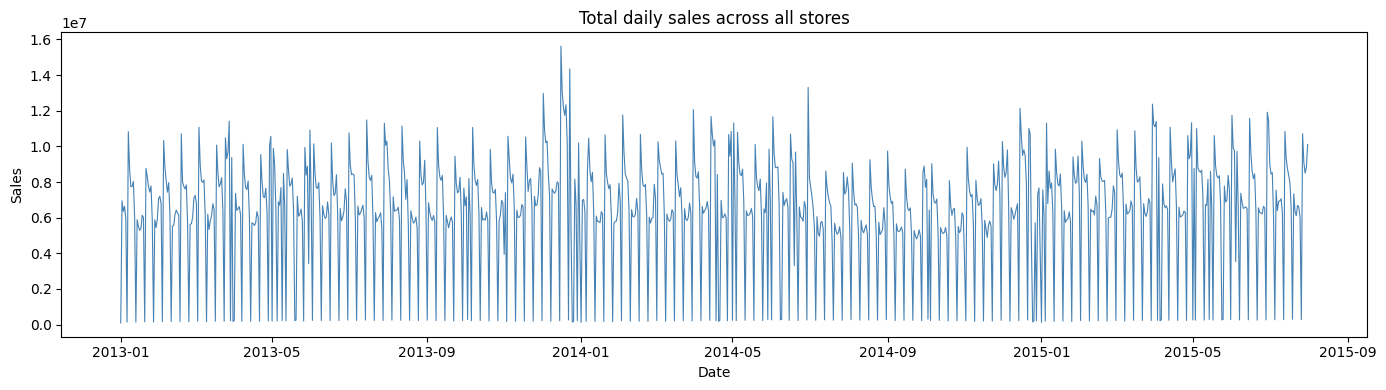

In [8]:
daily = df.groupby('Date')['Sales'].sum().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(daily['Date'], daily['Sales'], linewidth=0.8, color='steelblue')
plt.title('Total daily sales across all stores')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

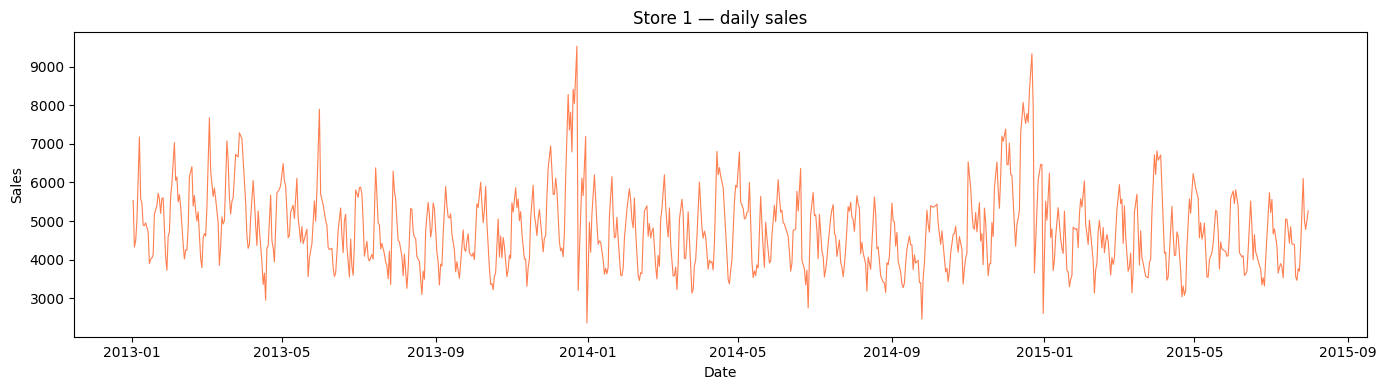

In [9]:
store1 = df[df['Store'] == 1].sort_values('Date')

plt.figure(figsize=(14, 4))
plt.plot(store1['Date'], store1['Sales'], linewidth=0.8, color='coral')
plt.title('Store 1 — daily sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

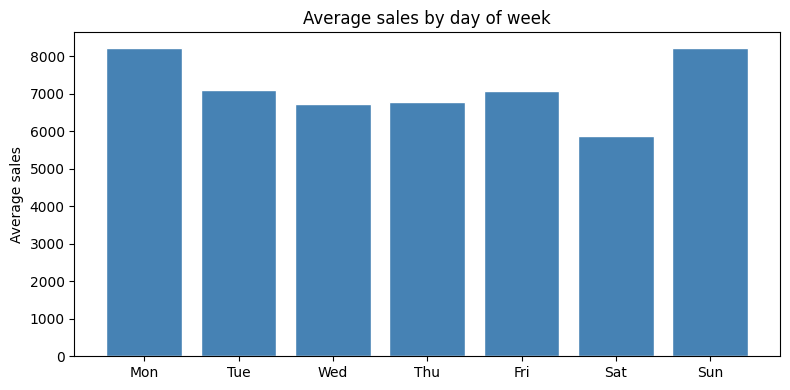

In [10]:
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekly_avg = df.groupby('DayOfWeek')['Sales'].mean()

plt.figure(figsize=(8, 4))
plt.bar(day_labels, weekly_avg.values, color='steelblue', edgecolor='white')
plt.title('Average sales by day of week')
plt.ylabel('Average sales')
plt.tight_layout()
plt.show()

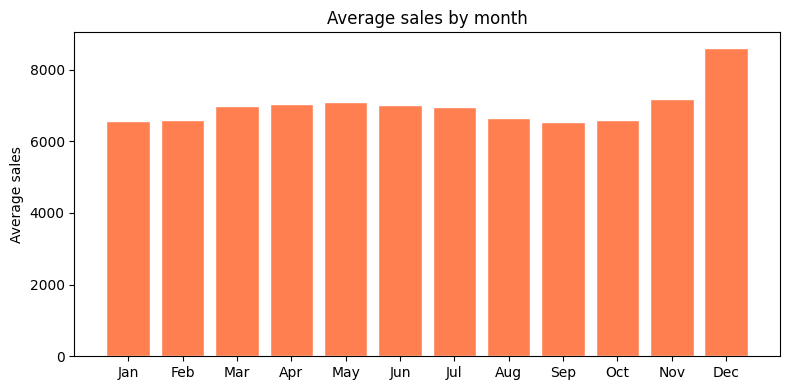

In [11]:
monthly_avg = df.groupby('Month')['Sales'].mean()

plt.figure(figsize=(8, 4))
plt.bar(range(1, 13), monthly_avg.values, color='coral', edgecolor='white')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Average sales by month')
plt.ylabel('Average sales')
plt.tight_layout()
plt.show()

<Figure size 700x400 with 0 Axes>

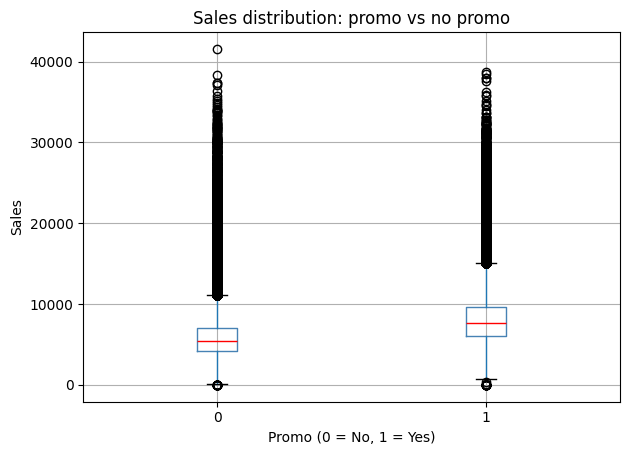

Avg sales without promo: 5,929
Avg sales with promo:    8,228
Promotion lift: 38.8%


In [12]:
plt.figure(figsize=(7, 4))
df.boxplot(column='Sales', by='Promo', 
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red'))
plt.title('Sales distribution: promo vs no promo')
plt.suptitle('')
plt.xlabel('Promo (0 = No, 1 = Yes)')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

promo_avg = df.groupby('Promo')['Sales'].mean()
lift = ((promo_avg[1] - promo_avg[0]) / promo_avg[0]) * 100
print(f"Avg sales without promo: {promo_avg[0]:,.0f}")
print(f"Avg sales with promo:    {promo_avg[1]:,.0f}")
print(f"Promotion lift: {lift:.1f}%")

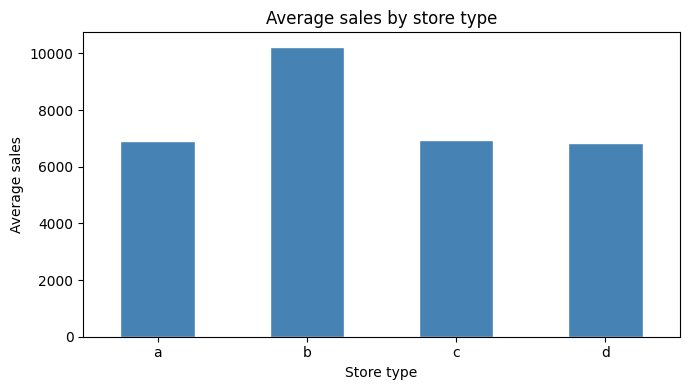

In [13]:
plt.figure(figsize=(7, 4))
df.groupby('StoreType')['Sales'].mean().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average sales by store type')
plt.xlabel('Store type')
plt.ylabel('Average sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

store1_sales = df[df['Store'] == 1].sort_values('Date')['Sales']

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(store1_sales, lags=60, ax=axes[0])
plot_pacf(store1_sales, lags=60, ax=axes[1])
axes[0].set_title('Autocorrelation (ACF) — Store 1')
axes[1].set_title('Partial Autocorrelation (PACF) — Store 1')
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [2]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(store1_sales)
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Critical values: {result[4]}")

if result[1] < 0.05:
    print("\nResult: Series is STATIONARY (p < 0.05) — no differencing needed for ARIMA")
else:
    print("\nResult: Series is NON-STATIONARY (p > 0.05) — will need differencing in ARIMA")

df.to_csv("data/processed_data.csv", index=False)

NameError: name 'store1_sales' is not defined